# 🌍 Hackathon IndabaX Cameroon 2026
## Starter Notebook - English
### *AI for Climate & Health Resilience*

---

| Step | Description |
|------|-------------|
| **1** | Setup & Data Loading |
| **2** | Exploratory Data Analysis (EDA) |
| **3** | Cleaning & Feature Engineering |
| **4** | Baseline Modelling |
| **5** | Next Steps |

## 📑 Table of Contents

- [1. Setup & Data Loading](#section-setup)

- [2. Exploratory Data Analysis (EDA)](#section-eda)

- [3. Cleaning & Feature Engineering](#section-cleaning)

- [4. Baseline Modelling](#section-baseline)

- [Going Further](#section-further)

<a id="section-setup"></a>

---
## 1. ⚙️ Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
SEED = 42

In [3]:
df = pd.read_excel('../data/Dataset_complet_Meteo.xlsx')

# Some numeric columns are stored as strings - fix this
num_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_duration', 'latitude', 'longitude'
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Dataset loaded: {df.shape[0]:,} obs x {df.shape[1]} variables")
print(f"   Period : {df['time'].min().date()} → {df['time'].max().date()}")
print(f"   Cities : {df['city'].nunique()} | Regions : {df['region'].nunique()}")
df.head(3)

Dataset loaded: 87,240 obs x 26 variables
   Period : 2020-01-01 → 2025-12-20
   Cities : 40 | Regions : 10


,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,NaN,NaN,34.0,2026-06-25 00:00:00,NaN,2020-01-01 06:22:00,...,0.0,NaN,NaN,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,NaN,NaN,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,NaN,NaN,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,NaN,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,NaN,2020-01-03 06:23:00,...,0.0,NaN,NaN,65,NaN,4.78,Bafia,Centre,4.75,11.23


<a id="section-eda"></a>

---
## 2. 🔍 Exploratory Data Analysis (EDA)

In [4]:
df[['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration']].describe().round(2)

,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,et0_fao_evapotranspiration
count,11508.00,47769.00,9378.00,69898.00,70121.00
mean,26.34,2.11,12.15,18.48,4.19
std,4.97,9.52,3.64,4.05,1.52
min,16.00,0.00,4.00,1.88,0.47
25%,23.00,0.00,10.00,15.87,3.23
50%,25.00,0.00,12.00,19.18,3.91
75%,31.20,0.50,14.00,21.63,4.81
max,38.20,251.10,36.60,26.79,12.31


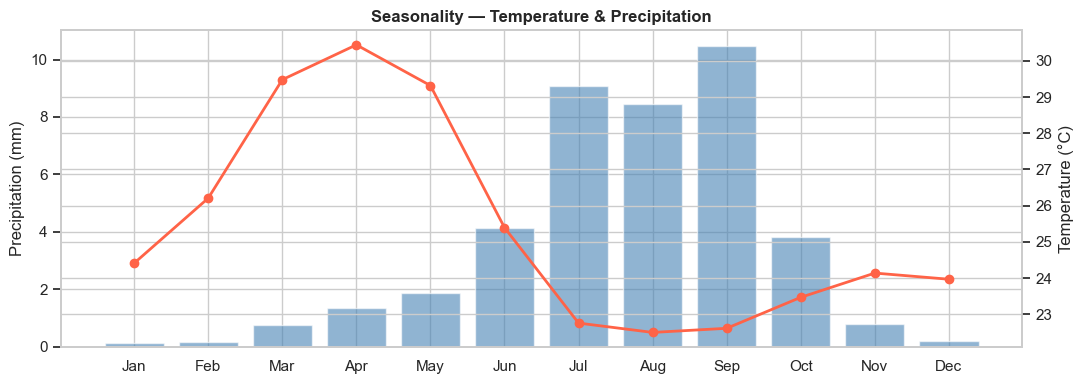

In [5]:
# ── National seasonality ──────────────────────────────────────────────────────
df['month'] = df['time'].dt.month
monthly = df.groupby('month').agg(
    temp_mean=('temperature_2m_mean', 'mean'),
    rain_mean=('precipitation_sum', 'mean')
)

fig, ax1 = plt.subplots(figsize=(11, 4))
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax1.bar(months, monthly['rain_mean'], color='steelblue', alpha=0.6, label='Precipitation (mm)')
ax2 = ax1.twinx()
ax2.plot(months, monthly['temp_mean'], color='tomato', marker='o', lw=2, label='Temperature (°C)')
ax1.set_title('Seasonality — Temperature & Precipitation', fontweight='bold')
ax1.set_ylabel('Precipitation (mm)'); ax2.set_ylabel('Temperature (°C)')
plt.tight_layout(); plt.show()

In [6]:
# ── Interactive map of 42 cities ──────────────────────────────────────────────
# Aggregate by city first, then take one coordinate per city
city_stats = df.groupby('city').agg(
    temp_mean=('temperature_2m_mean', 'mean'),
    radiation=('shortwave_radiation_sum', 'mean'),
    region=('region', 'first'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
).reset_index().round(2)

print(f"Cities on map: {len(city_stats)}")

fig = px.scatter_mapbox(
    city_stats, lat='latitude', lon='longitude',
    color='temp_mean', size='radiation', hover_name='city',
    hover_data={'region': True, 'latitude': False, 'longitude': False},
    color_continuous_scale='RdYlBu_r',
    zoom=5, mapbox_style='open-street-map',
    title='42 Cities — Average Temperature & Solar Radiation'
)
fig.update_layout(height=500)
fig.show()


Cities on map: 40


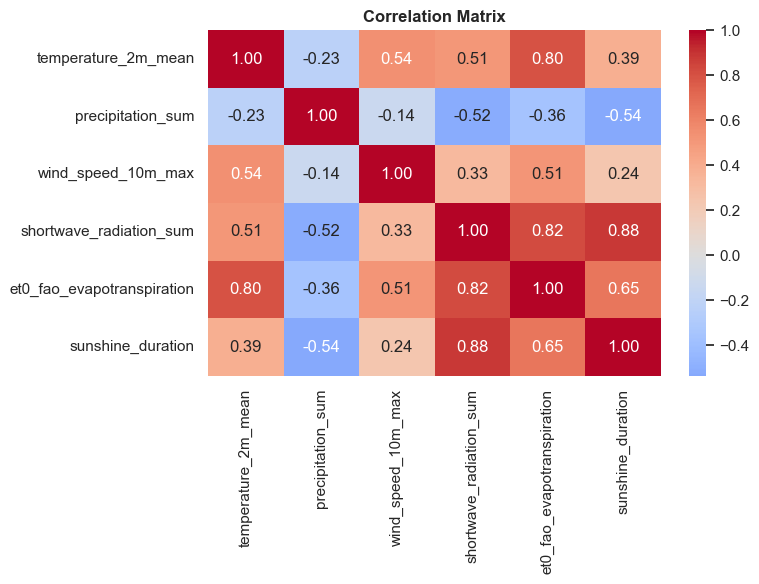

In [7]:
# ── Correlation matrix ────────────────────────────────────────────────────────
corr_cols = ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max',
             'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'sunshine_duration']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

<a id="section-cleaning"></a>

---
## 3. 🔧 Cleaning & Feature Engineering

In [10]:
# ── Temporal features ─────────────────────────────────────────────────────────
df['year']          = df['time'].dt.year
df['quarter']       = df['time'].dt.quarter
df['day_of_year']   = df['time'].dt.dayofyear
df['month_sin']     = np.sin(2 * np.pi * df['month'] / 12)  # cyclic encoding
df['month_cos']     = np.cos(2 * np.pi * df['month'] / 12)
df['is_dry_season'] = df['month'].isin([11,12,1,2,3]).astype(int)

# ── Derived meteorological features ──────────────────────────────────────────
df['temp_amplitude'] = df['temperature_2m_max'] - df['temperature_2m_min']
df['sunshine_ratio'] = df['sunshine_duration'] / (df['daylight_duration'] + 1e-6)
df['is_no_wind']     = (df['wind_speed_10m_max'] < 5).astype(int)  # air stagnation
df['is_no_rain']     = (df['precipitation_sum'] < 0.1).astype(int)  # no washout

# ── Lag features (time series) ────────────────────────────────────────────────
df = df.sort_values(['city', 'time']).reset_index(drop=True)
for lag in [1, 3, 7]:
    df[f'temp_lag{lag}'] = df.groupby('city')['temperature_2m_mean'].shift(lag)
    df[f'wind_lag{lag}'] = df.groupby('city')['wind_speed_10m_max'].shift(lag)

df['temp_roll7'] = df.groupby('city')['temperature_2m_mean'].transform(
    lambda x: x.rolling(7, min_periods=1).mean())

# ── Encode categorical variables ──────────────────────────────────────────────
df['region_enc'] = df['region'].astype('category').cat.codes
df['city_enc']   = df['city'].astype('category').cat.codes

print(f"Features built. Total columns: {df.shape[1]}")

Features built. Total columns: 46


In [11]:
# ── Build the PM2.5 proxy target ───────────────────────────────────────────────
#
# Without direct air quality measurements, we build a proxy
# based on conditions known to worsen air quality:
#   • High temperature + strong sunlight → photochemical reactions
#   • No wind → particle stagnation
#   • No rain → no washout effect
#   • Dry season → dust & bushfire smoke
#
# ⚠️ Improve this with real data from the Open-Meteo Air Quality API
#    See: README.md for the code to fetch PM2.5 directly!

df['pm25_proxy'] = (
    0.35 * df['temperature_2m_mean'].fillna(df['temperature_2m_mean'].mean())
    + 0.25 * df['shortwave_radiation_sum'].fillna(0)
    + 0.20 * df['et0_fao_evapotranspiration'].fillna(0)
    + 8.0  * df['is_no_wind']
    + 5.0  * df['is_no_rain']
    + 4.0  * df['is_dry_season']
).clip(lower=0)

print("PM2.5 proxy — summary:")
print(df['pm25_proxy'].describe().round(2))

PM2.5 proxy — summary:
count    87240.00
mean        16.79
std          4.95
min          5.60
25%         13.29
50%         15.19
75%         19.72
max         30.34
Name: pm25_proxy, dtype: float64


<a id="section-baseline"></a>

---
## 4. 🤖 Baseline Modelling

> **Goal:** Predict `pm25_proxy` — a composite air pollution risk index — from meteorological variables.

In [12]:
# ── Prepare modelling dataset ──────────────────────────────────────────────────
FEATURES = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'sunshine_ratio',
    'temp_amplitude', 'is_no_wind', 'is_no_rain', 'is_dry_season',
    'month_sin', 'month_cos', 'day_of_year',
    'temp_lag1', 'temp_lag7', 'wind_lag1', 'temp_roll7',
    'latitude', 'longitude', 'region_enc', 'city_enc'
]
TARGET = 'pm25_proxy'

df_model = df[FEATURES + [TARGET]].copy()

# Fill NaN in lag features (expected at start of each city's series)
# and residual NaN with column median
for col in FEATURES:
    if df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Only drop rows where the target is missing
df_model = df_model.dropna(subset=[TARGET])

X, y = df_model[FEATURES], df_model[TARGET]

# Temporal split — NEVER use random split for time series!
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")


Train: 69,792 | Test: 17,448


In [13]:
# ── Train the model ────────────────────────────────────────────────────────────
model = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=SEED)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Performance:")
print(f"   R²   = {r2_score(y_test, y_pred):.4f}")
print(f"   MAE  = {mean_absolute_error(y_test, y_pred):.4f}")

Performance:
   R²   = 0.9984
   MAE  = 0.0812


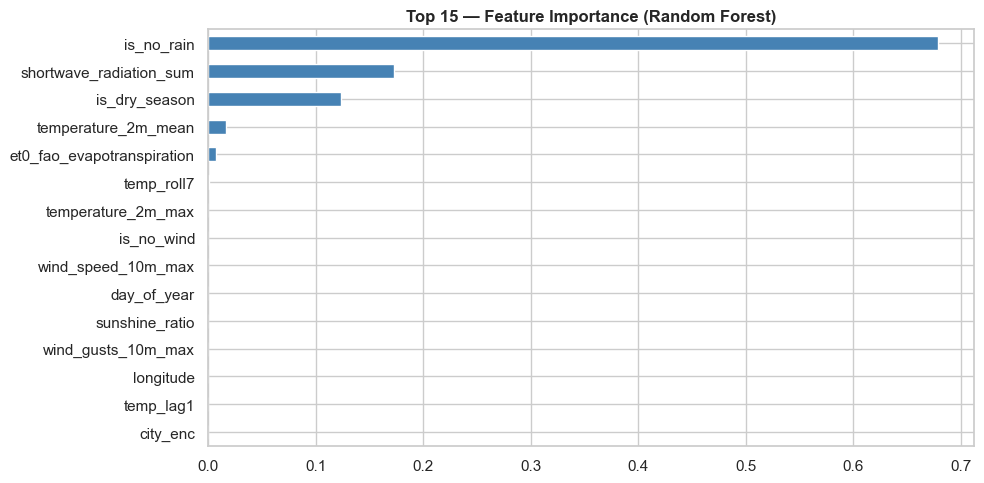

In [14]:
# ── Feature importance ────────────────────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 — Feature Importance (Random Forest)', fontweight='bold')
plt.tight_layout(); plt.show()

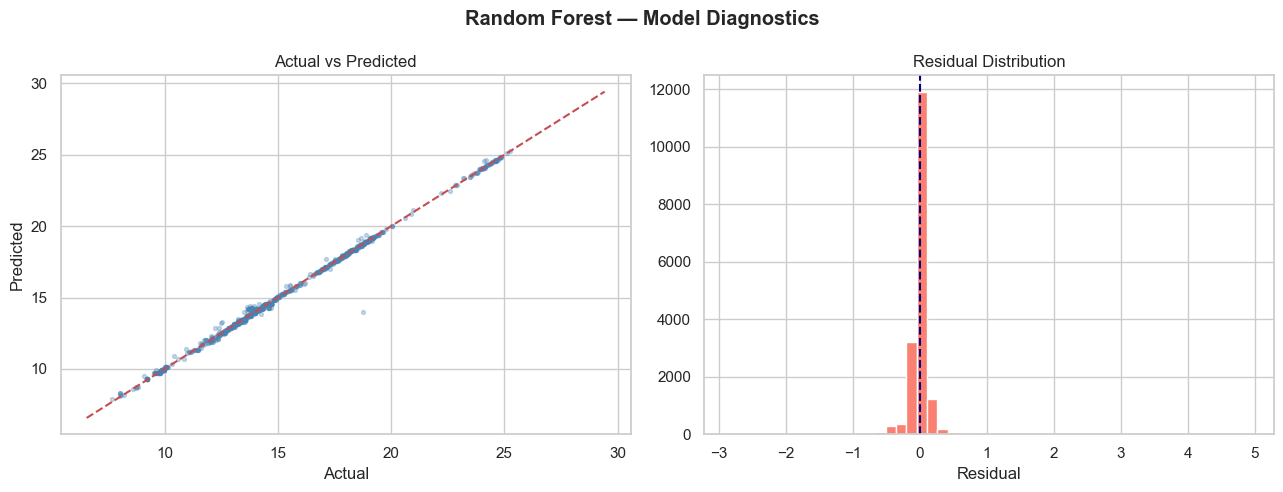

In [15]:
# ── Predictions vs Ground Truth ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
axes[0].scatter(y_test[:1000], y_pred[:1000], alpha=0.3, s=8, color='steelblue')
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set(xlabel='Actual', ylabel='Predicted', title='Actual vs Predicted')

# Residuals
axes[1].hist(y_test.values - y_pred, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0, color='navy', lw=1.5, ls='--')
axes[1].set(xlabel='Residual', title='Residual Distribution')

plt.suptitle('Random Forest — Model Diagnostics', fontweight='bold')
plt.tight_layout(); plt.show()

<a id="section-further"></a>
## 💡 Going Further

### ⏱️ Time Series Models
Prophet, ARIMA, LSTM, Temporal Fusion Transformer, XGBoost/LightGBM with lag features.

### 🗺️ Spatio-Temporal Models
Combine GPS coordinates and temporal lags (already done here ✅), or go further with ConvLSTM or Graph Neural Networks.

> 💡 A simple, well-justified solution beats a complex model poorly understood.

---
<div align='center'>

**Good luck! 🚀🌍**  
*Hackathon IndabaX Cameroon 2026*

</div>
